# Explore your Black Box and train your first Machine Learning Model
In this interactive notebook, you can load your black box and explore its structure. 

In the end, you can also train a machine learning model on the Z' example black box that can be used to classify the signal and background processes.

In [2]:
# import all necessary packages
import os

import json
import awkward as ak

import torch
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import numpy as np

First, you need to change the `CONFIG_FILE` to the name of your config to make sure you use the correct black box.

In [3]:
# define the config of the black box you want to look at
CONFIG_FILE = "tmp_config.json"

with open(CONFIG_FILE, "r") as f:
    config = json.load(f)

checkpoint_dir = config["options"]["checkpoint_dir"]

### Load your black box
You can use this function to load the black box. 

In [4]:
# function to load the black box data and labels
def load_blackbox(checkpoint_dir=checkpoint_dir):

    data_file = os.path.join(checkpoint_dir, "blackbox_data.parquet")
    labels_file = os.path.join(checkpoint_dir, "blackbox_labels.parquet")

    # load blackbox
    print("\nLoading blackbox...")
    if not os.path.exists(data_file):
        raise RuntimeError(f"No final blackbox found: {data_file}")
    
    data = ak.from_parquet(data_file)
    print(f"Loaded {len(data)} events from {data_file}")

    # load labels
    print("\nLoading labels...")
    if not os.path.exists(labels_file):
        raise RuntimeError(f"No final blackbox found: {labels_file}")
    
    labels = ak.from_parquet(labels_file)
    print(f"Loaded {len(labels)} labels from {labels_file}")


    return data, labels

By calling the function like that, the data is stored in `data` an the labels in `labels`.
The print statements show you how many events were loaded.

In [5]:
# load the data and labels
data, labels = load_blackbox()


Loading blackbox...
Loaded 140134 events from blackbox_checkpoint/blackbox_data.parquet

Loading labels...
Loaded 140134 labels from blackbox_checkpoint/blackbox_labels.parquet


### Explore the output
Let us first have a look at the whole data structure. The data is stored event-wise. The variables are sorted in different fields like `lep` or `jet`. For each field, the variables are stored in arrays.

In [6]:
# look at the whole data structure
data

<Array [{lep: {...}, jet: {...}, ...}, ...] type='140134 * {lep: {pt: var *...'>

You can access specific fields like that:

In [7]:
# look at the lep field
data.lep

<Array [{pt: [19.4, ...], eta: ..., ...}, ...] type='140134 * {pt: var * fl...'>

The labels are saved in an array, 1 meaning signal and 0 background.

In [8]:
# have a look at the labels
labels

<Array [0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0] type='140134 * int64'>

## Machine Learning
Now let us use the Z' black box to train a neural network to classify signal and background events. Before you start, make sure that you have generated the example black box $Z^{\prime} \rightarrow \mu\mu$.

In principle you also can use this approach for your own black box, but depending on the final state of the process you might have to make some adaptions.

In [28]:
data, labels = load_blackbox("Zprime_blackbox_checkpoint")


Loading blackbox...
Loaded 52044887 events from Zprime_blackbox_checkpoint/blackbox_data.parquet

Loading labels...
Loaded 52044887 labels from Zprime_blackbox_checkpoint/blackbox_labels.parquet


First, we want to apply some basic preselection to the data. We only want to include events containing exactly two muons.

In [29]:
# event selection criteria
mask_exactly2leptons = data.lep.n == 2
# define mask with filter criterium
data_2lep = data[mask_exactly2leptons]
labels_2lep = labels[mask_exactly2leptons]

Use the mask to apply the preselection and find out how many events pass it:

In [30]:
print("Number of events in the original signal dataset:", len(data))
print("Number of events with at least 2 leptons:", len(data_2lep))

Number of events in the original signal dataset: 52044887
Number of events with at least 2 leptons: 18420141


We want the input of the model to have an efficient and practical format. For that, we use torch tensors.

In [31]:
lepton0_pt_tensor  = torch.tensor(data_2lep.lep.pt[:,0] , dtype=torch.float32)
lepton0_eta_tensor = torch.tensor(data_2lep.lep.eta[:,0], dtype=torch.float32)
lepton0_phi_tensor = torch.tensor(data_2lep.lep.phi[:,0], dtype=torch.float32)
lepton0_e_tensor   = torch.tensor(data_2lep.lep.e[:,0]  , dtype=torch.float32)

lepton1_pt_tensor  = torch.tensor(data_2lep.lep.pt[:,1] , dtype=torch.float32)
lepton1_eta_tensor = torch.tensor(data_2lep.lep.eta[:,1], dtype=torch.float32)
lepton1_phi_tensor = torch.tensor(data_2lep.lep.phi[:,1], dtype=torch.float32)
lepton1_e_tensor   = torch.tensor(data_2lep.lep.e[:,1]  , dtype=torch.float32)

In [32]:
# stack the tensors into a single tensor
input_tensor = torch.stack([lepton0_pt_tensor,
             lepton0_eta_tensor,
             lepton0_phi_tensor,
             lepton0_e_tensor,
             lepton1_pt_tensor,
             lepton1_eta_tensor,
             lepton1_phi_tensor,
             lepton1_e_tensor,
             ], dim=1)

We want to make sure to have the same number of signal and background events. Therefore, both classes are treated equally in the training process.

In [33]:
signal_idx = np.where(labels_2lep == 1)[0]
background_idx = np.where(labels_2lep == 0)[0]

n = min(len(signal_idx), len(background_idx))

rng = np.random.default_rng(4)

signal_idx = rng.choice(
    signal_idx,
    size=n,
    replace=False
)

background_idx = rng.choice(
    background_idx,
    size=n,
    replace=False
)

selected_idx = np.concatenate([
    signal_idx,
    background_idx
])

# Durchmischen
rng.shuffle(selected_idx)

input_tensor = input_tensor[selected_idx]
labels_2lep = labels_2lep[selected_idx]

Next, we define a target, namely the labels. The model should learn to predict the label of an event from its kinematic features.

In [34]:
target_tensor = torch.tensor(labels_2lep, dtype=torch.float32)

We train the model on 80% of the data. The remaining 20% are used in the end to see if the model actually has learnt something and can also correctly classify events it has not seen during the training.

In [35]:
# train test split
X_train, X_test = train_test_split(input_tensor, test_size=0.2, random_state=4)
Y_train, Y_test = train_test_split(target_tensor, test_size=0.2, random_state=4)

Scaling the data helps the model to learn more efficient and reliable.

In [36]:
# Compute the mean and standard deviation
mean = X_train.mean(dim=0, keepdim=True)
std = X_train.std(dim=0, keepdim=True)

# Transform step: Apply the standardization formula
X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

In [37]:
device = "cpu"
X_train_scaled = X_train_scaled.to(device)
X_test_scaled = X_test_scaled.to(device)

Y_train = Y_train.to(device)
Y_test = Y_test.to(device)

Now, the model is defined. It expects eight inputs, as we want to include energy, transverse momentum, pseudorapidity and azimuthal angel of both muons. It has one hidden layer and an output that represents the probability of an event to be signal or background.

You can experiment with the number of hidden layers and nodes to see how this effects the model performance.

In [38]:
model = nn.Sequential(
    nn.Linear(8, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid(),
)

# Our model should live on the same device as our tensors
model = model.to(device)

In [39]:
# Define the loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

Now, we can start the training process. During 300 epochs, the model learns to predict the label of an event based on its kinematic variables and event topology.

If you want to run this part again later, make sure to first initialise the model again to reset previous training.

In [40]:
train_losses = []
test_losses = []

N_epochs = 300

for epoch in range(N_epochs):

    model.train()
    # tell the optimizer to begin an optimization step
    optimizer.zero_grad()

    # forward pass
    # use the model as a prediction function: features → predictions
    predictions = model(X_train_scaled)

    # compute the loss between these predictions and the intended targets
    loss = criterion(predictions.squeeze(), Y_train)

    # Compute the gradients of the loss wrt the trainable parameters
    loss.backward()

    # Update the model parameters based on the gradients
    optimizer.step()

    # Purely for monitoring and visualisation: keeping track of the losses
    train_losses.append(loss.item())


    # validation
    model.eval()

    with torch.no_grad():
        test_predictions = model(X_test_scaled)
        test_loss = criterion(test_predictions.squeeze(), Y_test)

    test_losses.append(test_loss.item())

    print(
        f'Epoch [{epoch + 1}/{N_epochs}], '
        f'Train Loss: {loss.item():.4f}, '
        f'Test Loss: {test_loss.item():.4f}')

Epoch [1/300], Train Loss: 0.7227, Test Loss: 0.6950
Epoch [2/300], Train Loss: 0.6955, Test Loss: 0.6709
Epoch [3/300], Train Loss: 0.6709, Test Loss: 0.6485
Epoch [4/300], Train Loss: 0.6483, Test Loss: 0.6274
Epoch [5/300], Train Loss: 0.6271, Test Loss: 0.6069
Epoch [6/300], Train Loss: 0.6065, Test Loss: 0.5864
Epoch [7/300], Train Loss: 0.5860, Test Loss: 0.5656
Epoch [8/300], Train Loss: 0.5651, Test Loss: 0.5441
Epoch [9/300], Train Loss: 0.5435, Test Loss: 0.5219
Epoch [10/300], Train Loss: 0.5211, Test Loss: 0.4989
Epoch [11/300], Train Loss: 0.4979, Test Loss: 0.4751
Epoch [12/300], Train Loss: 0.4739, Test Loss: 0.4509
Epoch [13/300], Train Loss: 0.4493, Test Loss: 0.4263
Epoch [14/300], Train Loss: 0.4244, Test Loss: 0.4016
Epoch [15/300], Train Loss: 0.3993, Test Loss: 0.3772
Epoch [16/300], Train Loss: 0.3745, Test Loss: 0.3533
Epoch [17/300], Train Loss: 0.3501, Test Loss: 0.3302
Epoch [18/300], Train Loss: 0.3265, Test Loss: 0.3083
Epoch [19/300], Train Loss: 0.3040, T

The model trains by minimising the so-called loss, which is a measure for the model performance. The better it classifies events on average, the smaller is the loss. When plotting the loss functions of the training and the test data, you can see how the model learns over the course of the epochs.

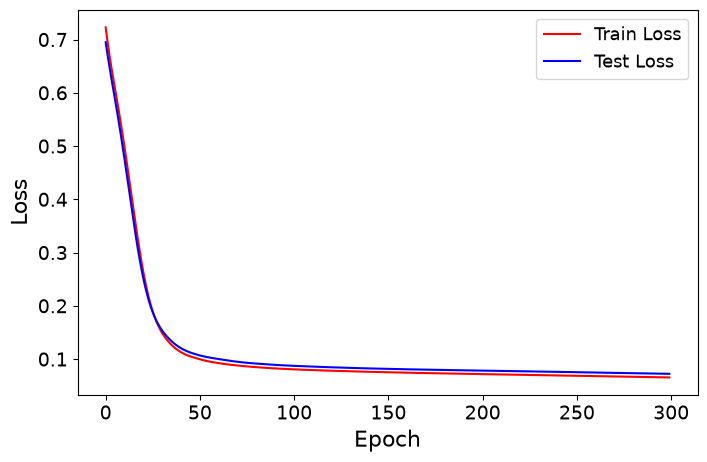

In [41]:
# plot loss function for training and validation sets
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss', color='red')
plt.plot(test_losses, label='Test Loss', color='blue')

plt.xlabel('Epoch', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.tick_params(axis="both", which="major", labelsize=14)
plt.legend(fontsize=13)
plt.savefig("loss.pdf")
plt.show()

Finally, we want to determine whether the model is able to correctly classify the events in the test sample. To do this, we run the model on the test data. This produces a score between 0 and 1 for each event. A score of 1 means that the model classifies the event as signal with a probability of 100%, while a score of 0 means that the model classifies the event as background with a probability of 100%.

The plot shows the scores for signal events in blue and for background events in orange.

tensor([[0.0687],
        [1.0000],
        [0.9997],
        ...,
        [1.0000],
        [1.0000],
        [0.0159]])
0.9771615008156607


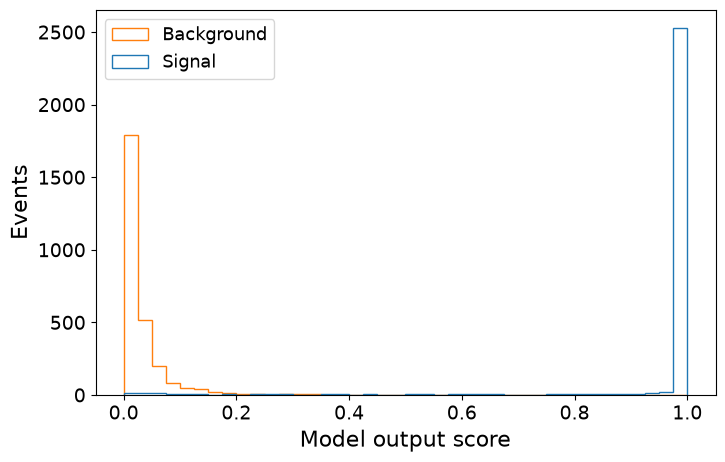

In [42]:
# Model evaluation is simple: call the model
# We detach the array
y_pred = model(X_test_scaled).detach()
print(y_pred)

threshold = 0.5
y_pred_labels = (y_pred >= threshold).float()

accuracy = accuracy_score(Y_test, y_pred_labels)
print(accuracy)

# Plotting the model outputs for signal and background separately
signal_scores = y_pred[Y_test == 1].flatten()
background_scores = y_pred[Y_test == 0].flatten()
plt.figure(figsize=(8, 5))
plt.hist([signal_scores,background_scores], bins=40, histtype='step', label=['Signal','Background'])
plt.legend(fontsize=13)
plt.xlabel('Model output score', fontsize=16)
plt.ylabel('Events', fontsize=16)
plt.tick_params(axis="both", which="major", labelsize=14)
plt.savefig("pytorch.pdf", bbox_inches="tight")
plt.show()